# Import Required Libraries
Import the necessary libraries such as `networkx` for plotting graphs and `json` to load the dataset.

In [1]:
import os
import sys
import json
import random
import networkx as nx
import matplotlib.pyplot as plt
from pathlib import Path
import textwrap

# Ensure project root is in sys.path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.utils.project_paths import get_paths
paths = get_paths()
RAW_FEATURES_DIR = Path(paths["raw_features_dir"])
DATA_FILE = PROJECT_ROOT / "data" / "data.jsonl"

# Load Sample Data
Select a few random examples from `data.jsonl` that have successfully processed graph files in `RAW_FEATURES_DIR`.

In [2]:
# Get all extracted json files
extracted_methods = []
if RAW_FEATURES_DIR.exists():
    extracted_methods = [f.stem for f in RAW_FEATURES_DIR.iterdir() if f.is_file() and f.suffix == '.json']

print(f"Total extracted methods available: {len(extracted_methods)}")

# Load a random sample from data.jsonl that was successfully extracted
sample_id = random.choice(extracted_methods) if extracted_methods else None

sample_code = ""
if sample_id:
    with open(DATA_FILE, "r", encoding="utf-8") as f:
        for line in f:
            record = json.loads(line)
            if str(record.get("idx")) == sample_id:
                sample_code = record.get("func", "")
                break

print(f"Selected Method ID for visualization: {sample_id}")

Total extracted methods available: 9126
Selected Method ID for visualization: 229795


# Visualizing Output
We will print the raw Java code and draw the extracted layered graphs (AST, CFG, DDG).

<h3 style='text-align: center;'>Method: 229795</h3>

```java
    public static void doVersionCheck(View view) {
        view.showWaitCursor();
        try {
            URL url = new URL(jEdit.getProperty("version-check.url"));
            InputStream in = url.openStream();
            BufferedReader bin = new BufferedReader(new InputStreamReader(in));
            String line;
            String version = null;
            String build = null;
            while ((line = bin.readLine()) != null) {
                if (line.startsWith(".version")) version = line.substring(8).trim(); else if (line.startsWith(".build")) build = line.substring(6).trim();
            }
            bin.close();
            if (version != null && build != null) {
                if (jEdit.getBuild().compareTo(build) < 0) newVersionAvailable(view, version, url); else {
                    GUIUtilities.message(view, "version-check" + ".up-to-date", new String[0]);
                }
            }
        } catch (IOException e) {
            String[] args = { jEdit.getProperty("version-check.url"), e.toString() };
            GUIUtilities.error(view, "read-error", args);
        }
        view.hideWaitCursor();
    }

```

/Users/ali/.pyenv/versions/3.13.1/lib/python3.13/site-packages/networkx/readwrite/json_graph/node_link.py:287: FutureWarning: 
The default value will be changed to `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_graph(data, edges="links") to preserve current behavior, or
  nx.node_link_graph(data, edges="edges") for forward compatibility.
  warnings.warn(


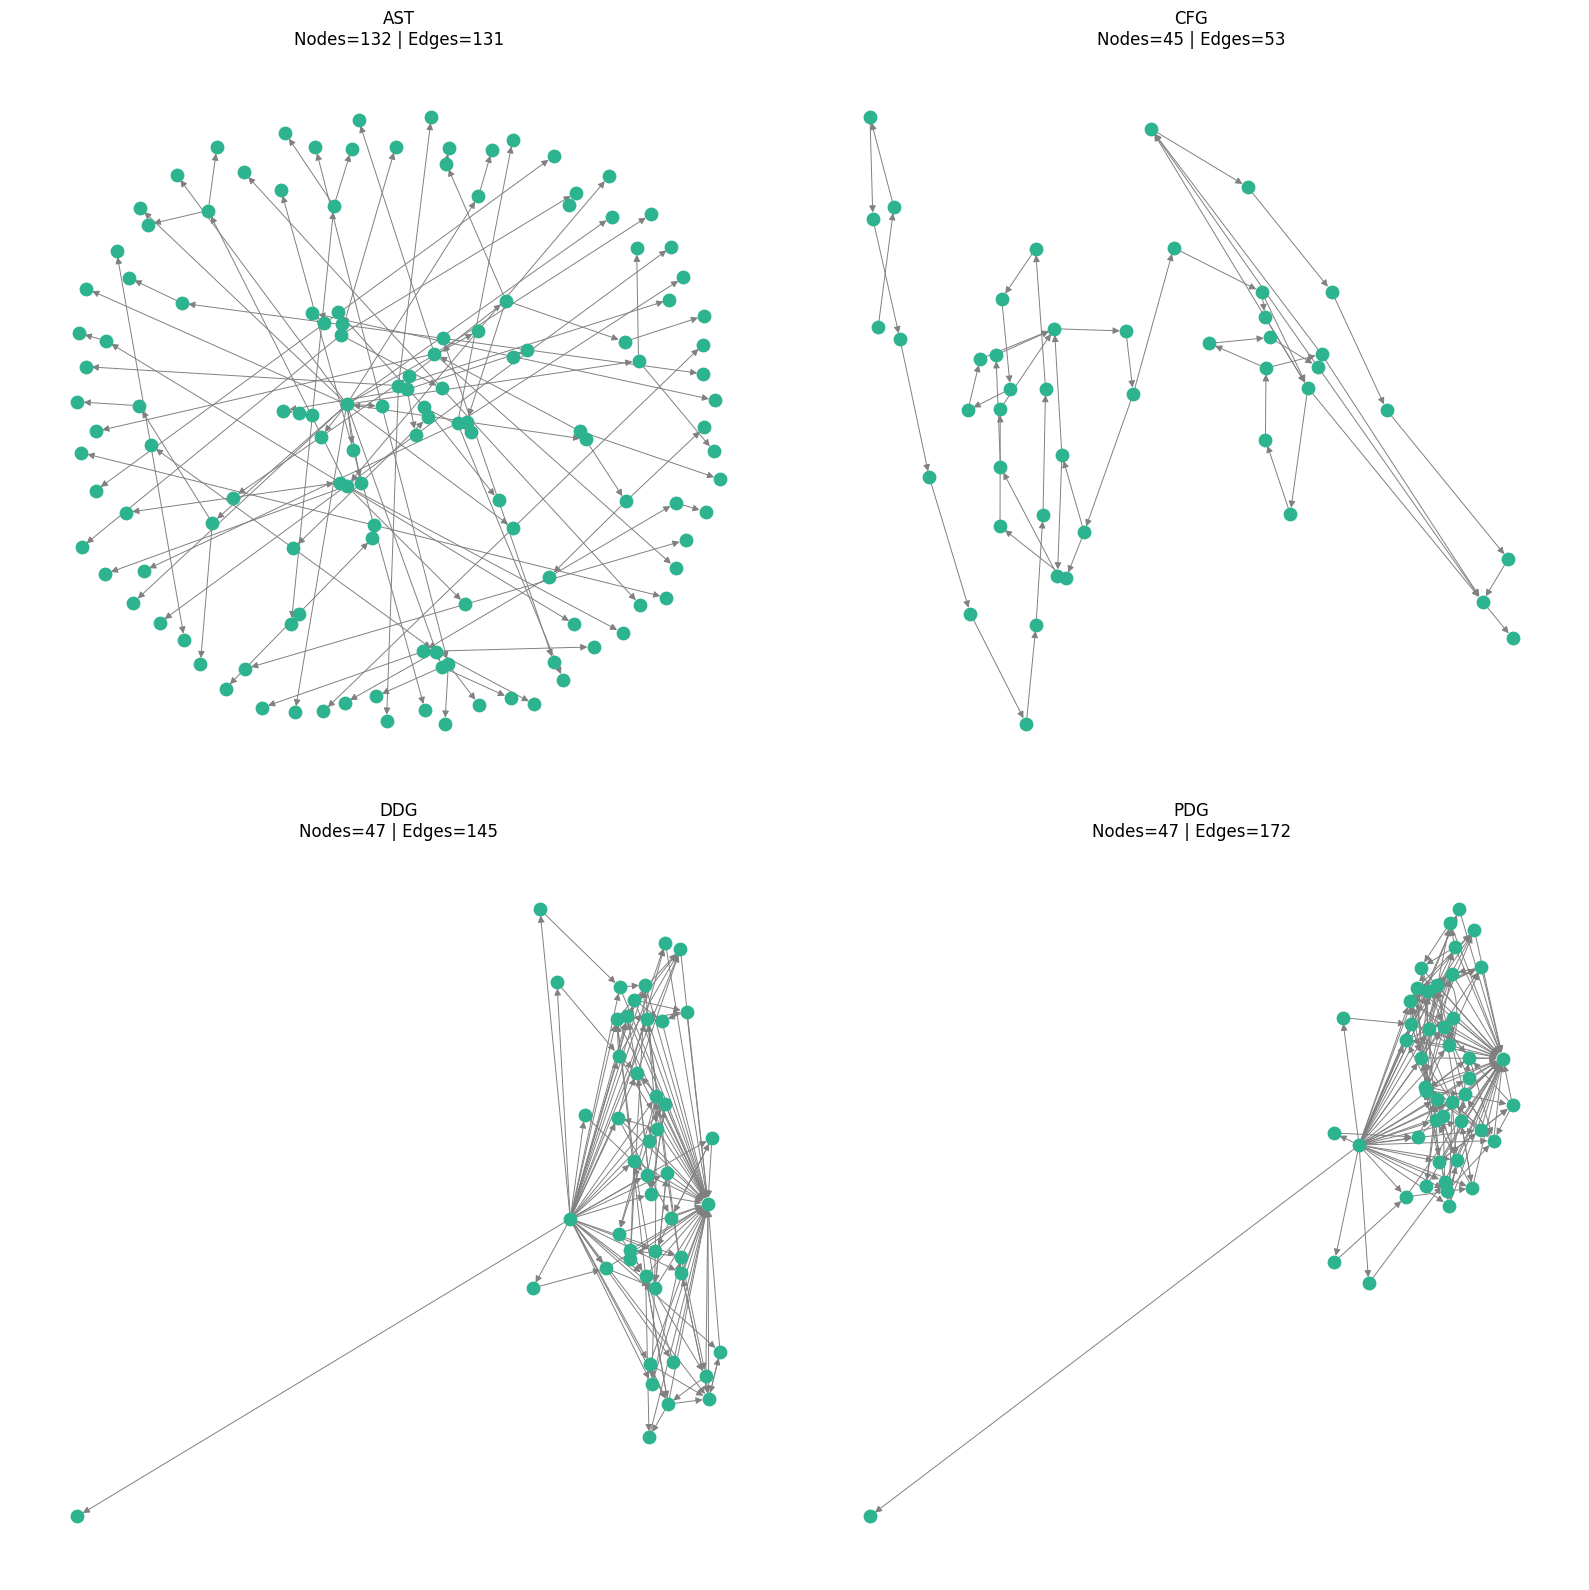

In [3]:
from IPython.display import display, Markdown

def plot_graph(g_data, title, ax):
    """Draw a networkx graph clean and small node style"""
    try:
        G = nx.node_link_graph(g_data)
    except Exception:
        ax.set_title(f"{title}\n(Invalid/Empty)", fontsize=14)
        ax.axis('off')
        return
        
    if G.number_of_nodes() == 0:
        ax.set_title(f"{title}\n(Empty)", fontsize=14)
        ax.axis('off')
        return
        
    # Kamada-Kawai or Spring layout
    pos = nx.spring_layout(G, seed=42)
    
    # Draw like the provided image: light sea-green nodes, no heavy labels
    nx.draw(G, pos, ax=ax, with_labels=False,
            node_color='#2db38f', edge_color='gray', node_size=80, 
            arrowsize=10, width=0.7)
            
    ax.set_title(f"{title}\nNodes={G.number_of_nodes()} | Edges={G.number_of_edges()}", fontsize=12)

if sample_id:
    # 1. Display Code Beautifully (like an image/screenshot with dark theme depending on IDE)
    display(Markdown(f"<h3 style='text-align: center;'>Method: {sample_id}</h3>"))
    display(Markdown(f"```java\n{sample_code}\n```"))
    
    # Load JSON features
    json_path = RAW_FEATURES_DIR / f"{sample_id}.json"
    with open(json_path, "r", encoding="utf-8") as f:
        data = json.load(f)
        features = data.get("features", {})
        
    # 2. Plot the graphs below it
    # We'll use a 2x2 grid so they are somewhat side-by-side but large enough
    fig, axes = plt.subplots(2, 2, figsize=(16, 16))
    
    plot_graph(features.get('ast', {}).get('graph_data', {}), "AST", axes[0, 0])
    plot_graph(features.get('cfg', {}).get('graph_data', {}), "CFG", axes[0, 1])
    plot_graph(features.get('ddg', {}).get('graph_data', {}), "DDG", axes[1, 0])
    plot_graph(features.get('pdg', {}).get('graph_data', {}), "PDG", axes[1, 1])
    
    # Remove borders
    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()